In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
df = pd.read_csv(r'C:\Users\mdsha\super-duper-funicular\data\health_data.csv')
print("Loaded data shape:", df.shape)
df.head()


Loaded data shape: (300, 12)


,age,weight,height,systolic,diastolic,cholesterol,glucose,smoker,exercise_level,comorbidity_score,treatment_type,outcome
0,58,103,169,102,88,273,139,1,1,3,A,1
1,71,47,177,132,104,187,192,1,2,3,A,1
2,48,64,157,105,93,221,158,0,2,2,B,1
3,34,103,188,149,82,282,97,0,3,1,B,1
4,62,80,150,109,96,239,135,1,1,2,B,0


In [4]:
# Cell 2 - info and summary stats
df.info()
df.describe(include='all').T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                300 non-null    int64 
 1   weight             300 non-null    int64 
 2   height             300 non-null    int64 
 3   systolic           300 non-null    int64 
 4   diastolic          300 non-null    int64 
 5   cholesterol        300 non-null    int64 
 6   glucose            300 non-null    int64 
 7   smoker             300 non-null    int64 
 8   exercise_level     300 non-null    int64 
 9   comorbidity_score  300 non-null    int64 
 10  treatment_type     300 non-null    object
 11  outcome            300 non-null    int64 
dtypes: int64(11), object(1)
memory usage: 28.3+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,300.0,NaN,NaN,NaN,49.93,17.793081,20.0,34.0,51.0,64.0,79.0
weight,300.0,NaN,NaN,NaN,76.95,18.510979,45.0,61.0,77.0,93.0,109.0
height,300.0,NaN,NaN,NaN,169.096667,11.542012,150.0,159.0,169.0,179.0,189.0
systolic,300.0,NaN,NaN,NaN,137.38,22.591078,100.0,118.75,137.0,156.0,177.0
diastolic,300.0,NaN,NaN,NaN,85.663333,14.183814,60.0,74.0,85.0,98.0,109.0
cholesterol,300.0,NaN,NaN,NaN,221.876667,43.591461,150.0,183.5,221.5,258.25,299.0
glucose,300.0,NaN,NaN,NaN,133.546667,38.37425,70.0,102.75,134.0,167.25,199.0
smoker,300.0,NaN,NaN,NaN,0.506667,0.500791,0.0,0.0,1.0,1.0,1.0
exercise_level,300.0,NaN,NaN,NaN,2.996667,1.431837,1.0,2.0,3.0,4.0,5.0
comorbidity_score,300.0,NaN,NaN,NaN,2.046667,1.389577,0.0,1.0,2.0,3.0,4.0


In [5]:
# Cell 3 - missingness
missing = df.isnull().sum().sort_values(ascending=False)
missing


age                  0
weight               0
height               0
systolic             0
diastolic            0
cholesterol          0
glucose              0
smoker               0
exercise_level       0
comorbidity_score    0
treatment_type       0
outcome              0
dtype: int64

In [6]:
# Cell 4 - target distribution
print(df['outcome'].value_counts())
print("Proportions:")
print(df['outcome'].value_counts(normalize=True))


outcome
1    234
0     66
Name: count, dtype: int64
Proportions:
outcome
1    0.78
0    0.22
Name: proportion, dtype: float64


In [7]:
# Cell 5 - simple imputation and save cleaned data

# Identify numeric and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Median impute numeric columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Mode impute categorical columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

# Save cleaned dataset
df.to_csv(r'C:\Users\mdsha\super-duper-funicular\data\health_data_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


<Figure size 1200x1000 with 0 Axes>

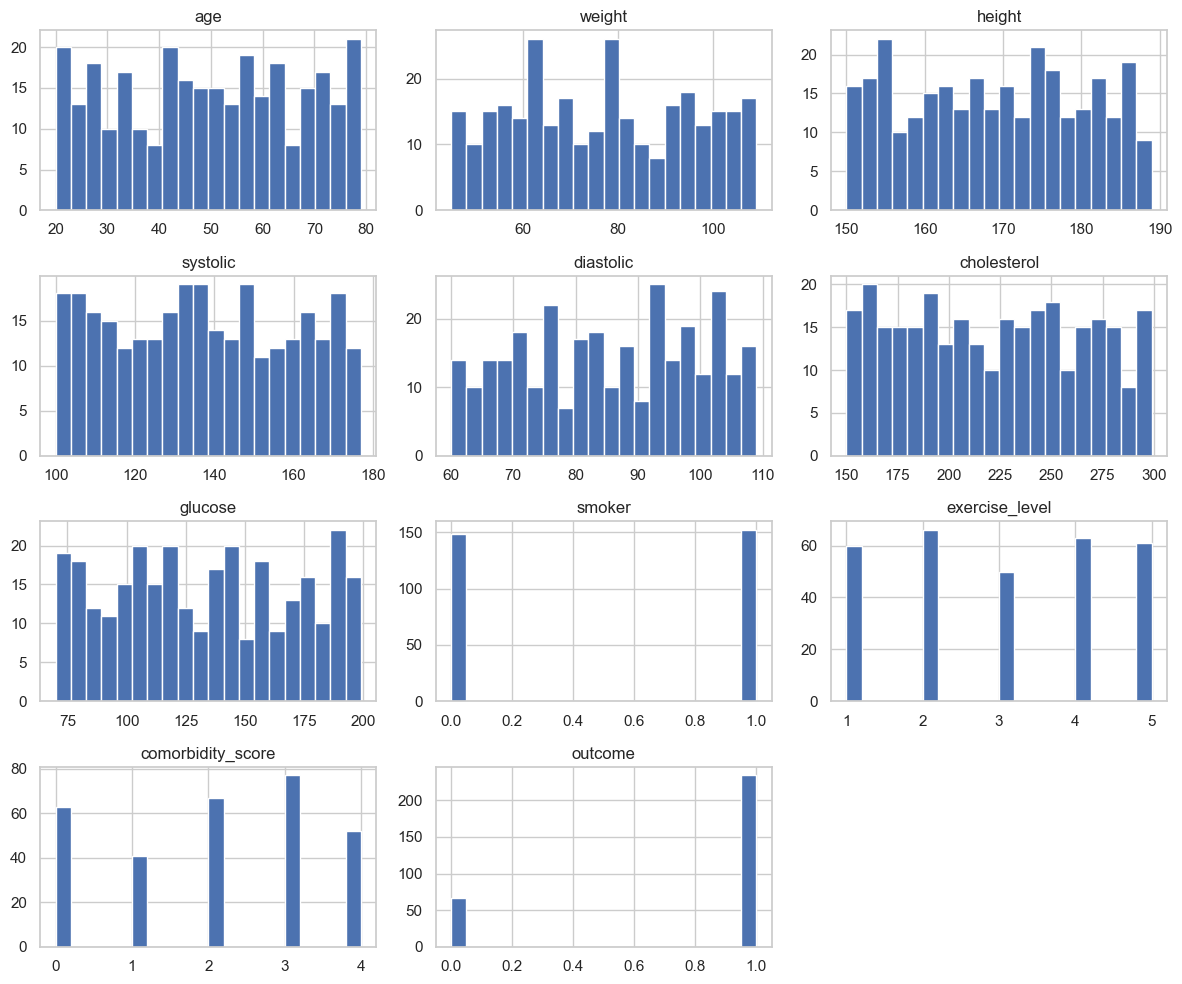

In [8]:
# Cell 6 - histograms for numeric features
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 10))
df[num_cols].hist(bins=20, figsize=(12,10))
plt.tight_layout()
plt.show()


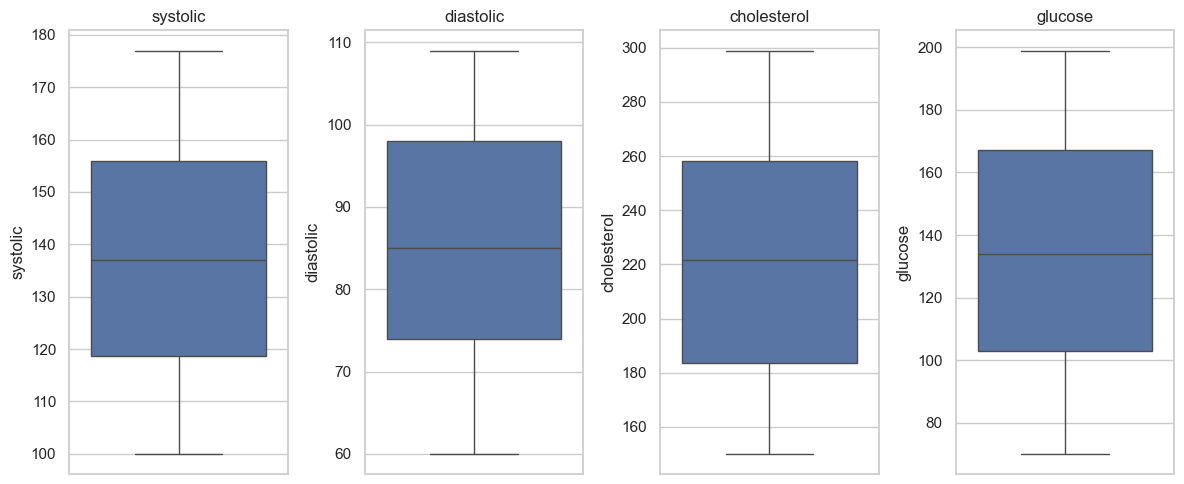

In [9]:
# Cell 7 - boxplots for key clinical features
plt.figure(figsize=(12, 5))

features = ['systolic', 'diastolic', 'cholesterol', 'glucose']
for i, col in enumerate(features):
    if col in df.columns:
        plt.subplot(1, 4, i+1)
        sns.boxplot(y=df[col])
        plt.title(col)

plt.tight_layout()
plt.show()


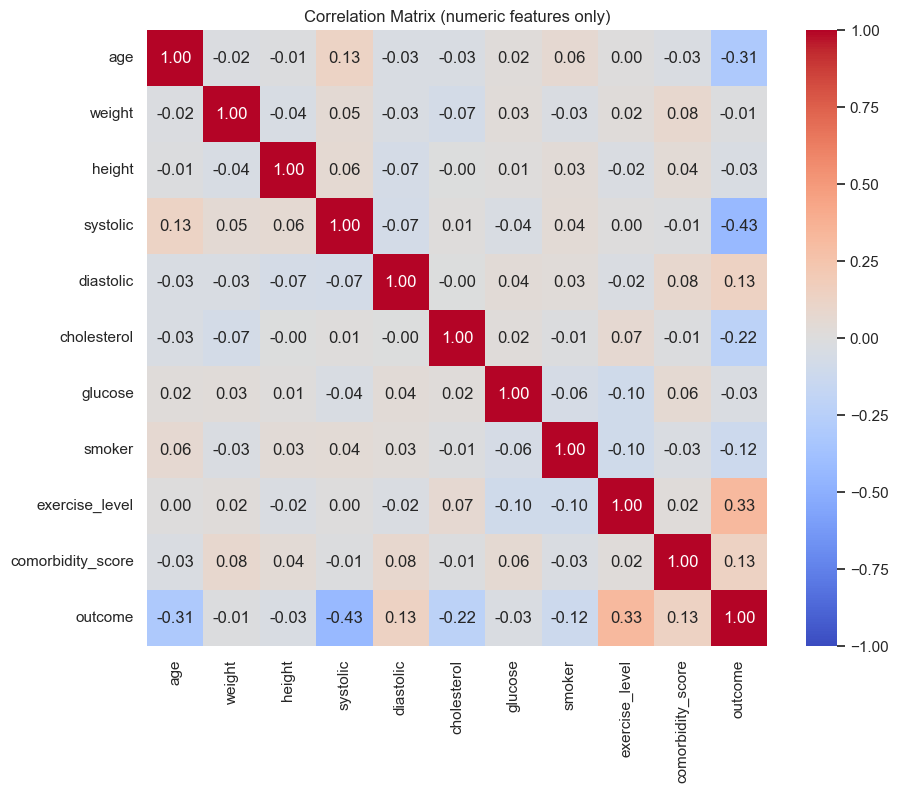

In [11]:

plt.figure(figsize=(10, 8))

num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix (numeric features only)")
plt.show()


In [12]:
# Cell 9 - detect outliers using IQR for numeric cols
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = {c: int(detect_outliers_iqr(num_df[c])) for c in num_df.columns}
outlier_counts


{'age': 0,
 'weight': 0,
 'height': 0,
 'systolic': 0,
 'diastolic': 0,
 'cholesterol': 0,
 'glucose': 0,
 'smoker': 0,
 'exercise_level': 0,
 'comorbidity_score': 0,
 'outcome': 66}

# EDA & Cleaning Summary

- **Dataset size:** 300 rows and 12 columns  
- **Missing values:** Handled using median (numeric) and mode (categorical)  
- **Target distribution (`outcome`):**  
  - Count of Outcome=1 and Outcome=0 shown above  
- **Plots generated:**  
  - Histograms of numeric features  
  - Boxplots for clinical values (systolic, diastolic, cholesterol, glucose)  
  - Correlation heatmap (numeric columns only)  
- **Outliers:** Detected using IQR method  
- **Cleaning completed:**  
  - Dataset saved as `health_data_cleaned.csv` in the `/data/` folder  

This cleaned dataset will now be used for model training in the next notebook.
